In [1]:
import pandas as pd
print("Environment working")

Environment working


### Step 3 — Exploratory Data Analysis

#### Cell 1: Load curated data & set up plotting

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/metadata_curated.csv')
print(df.shape)
df.head()

(112120, 13)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Age_Flag
0,00000001_000.png,Cardiomegaly,0,1,58.0,M,PA,2682,2749,0.143,0.143,NaN,False
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58.0,M,PA,2894,2729,0.143,0.143,NaN,False
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58.0,M,PA,2500,2048,0.168,0.168,NaN,False
3,00000002_000.png,No Finding,0,2,81.0,M,PA,2500,2048,0.171,0.171,NaN,False
4,00000003_000.png,Hernia,0,3,81.0,F,PA,2582,2991,0.143,0.143,NaN,False


#### Cell 2: Parse disease labels into binary columns

In [3]:
disease_list = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
                 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
                 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']

for disease in disease_list:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

df['No_Finding'] = df['Finding Labels'].apply(lambda x: 1 if x == 'No Finding' else 0)

print(df[disease_list + ['No_Finding']].sum())

Atelectasis           11559
Cardiomegaly           2776
Effusion              13317
Infiltration          19894
Mass                   5782
Nodule                 6331
Pneumonia              1431
Pneumothorax           5302
Consolidation          4667
Edema                  2303
Emphysema              2516
Fibrosis               1686
Pleural_Thickening     3385
Hernia                  227
No_Finding            60361
dtype: int64


#### Cell 3: Disease distribution bar chart

/tmp/ipykernel_318381/1209470866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')


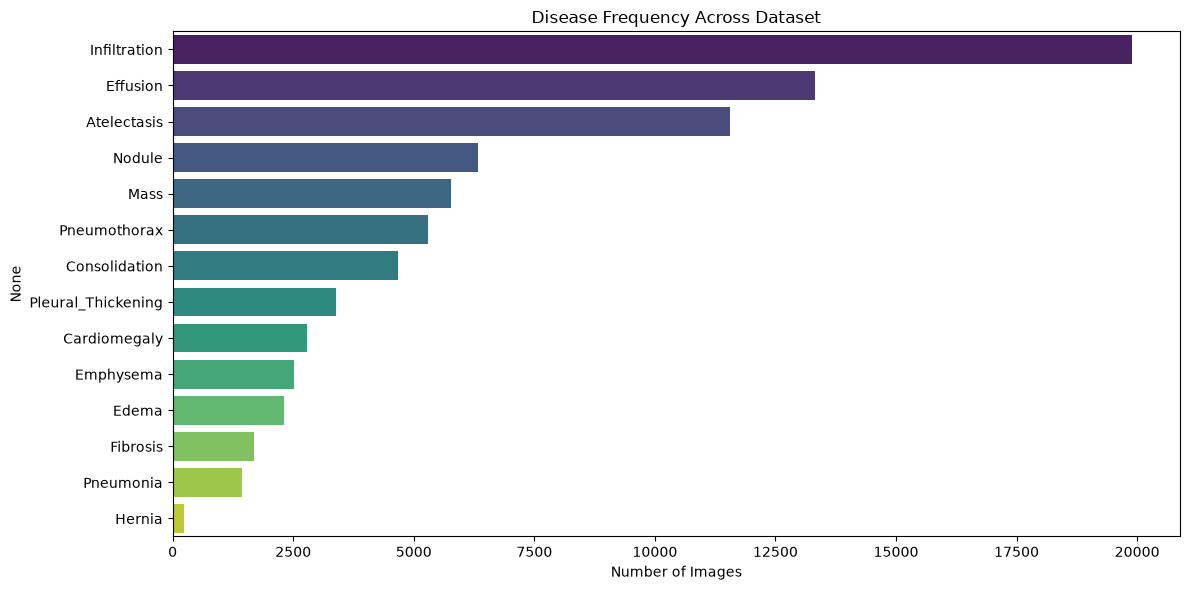

In [4]:
disease_counts = df[disease_list].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')
plt.title('Disease Frequency Across Dataset')
plt.xlabel('Number of Images')
plt.tight_layout()
plt.savefig('../outputs/disease_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

#### Cell 4: "No Finding" proportion

In [5]:
no_finding_pct = df['No_Finding'].mean() * 100
print(f"No Finding: {no_finding_pct:.1f}% of all images")

No Finding: 53.8% of all images


#### Cell 5: Number of diseases per image

/tmp/ipykernel_318381/3031459821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_diseases', data=df, palette='mako')


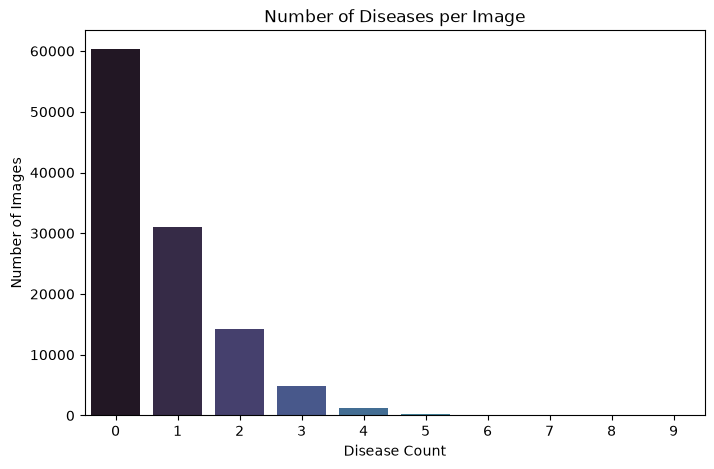

In [6]:
df['num_diseases'] = df[disease_list].sum(axis=1)

plt.figure(figsize=(8,5))
sns.countplot(x='num_diseases', data=df, palette='mako')
plt.title('Number of Diseases per Image')
plt.xlabel('Disease Count')
plt.ylabel('Number of Images')
plt.show()

#### Cell 6: Label co-occurrence heatmap

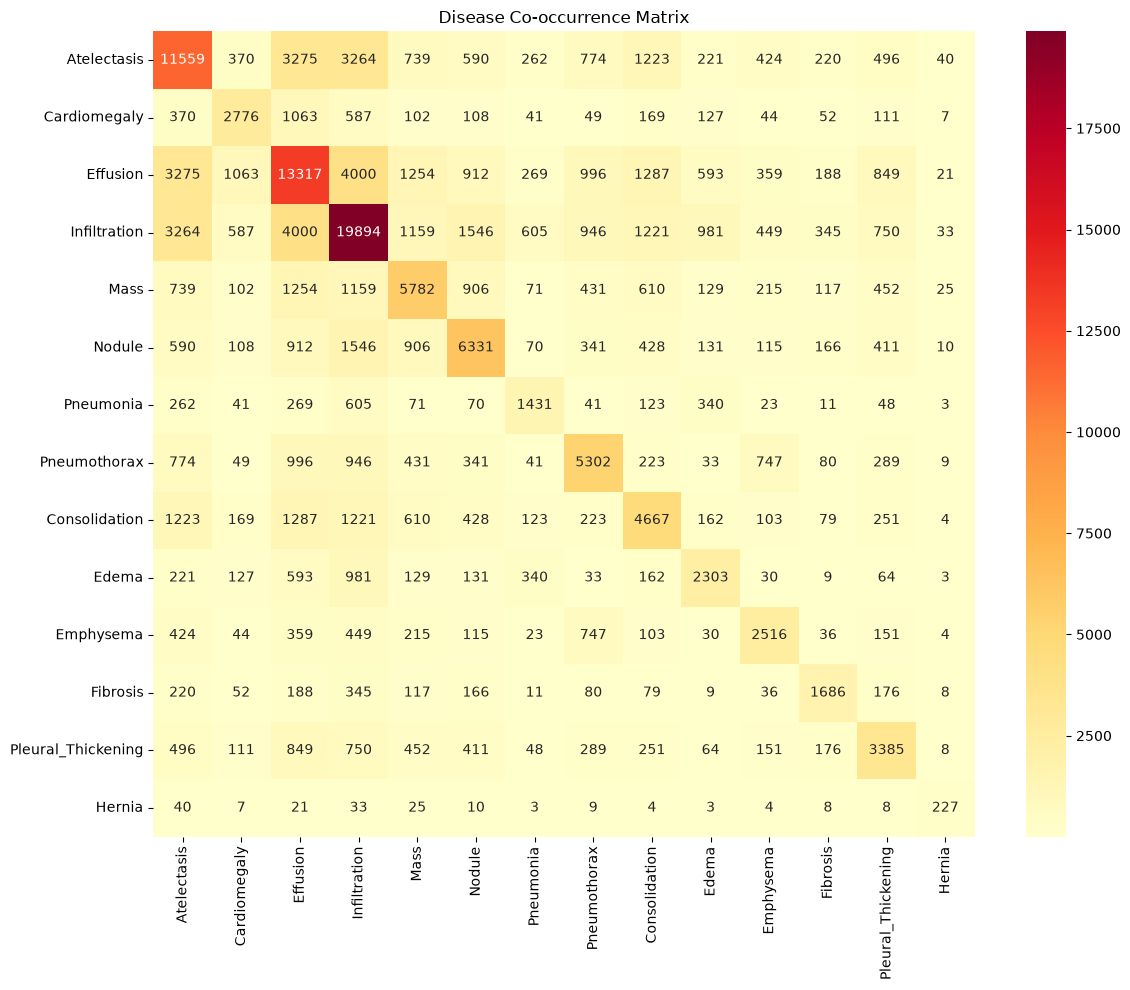

In [7]:
co_occurrence = df[disease_list].T.dot(df[disease_list])

plt.figure(figsize=(12,10))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Disease Co-occurrence Matrix')
plt.tight_layout()
plt.show()

#### Cell 7: Sample image grid

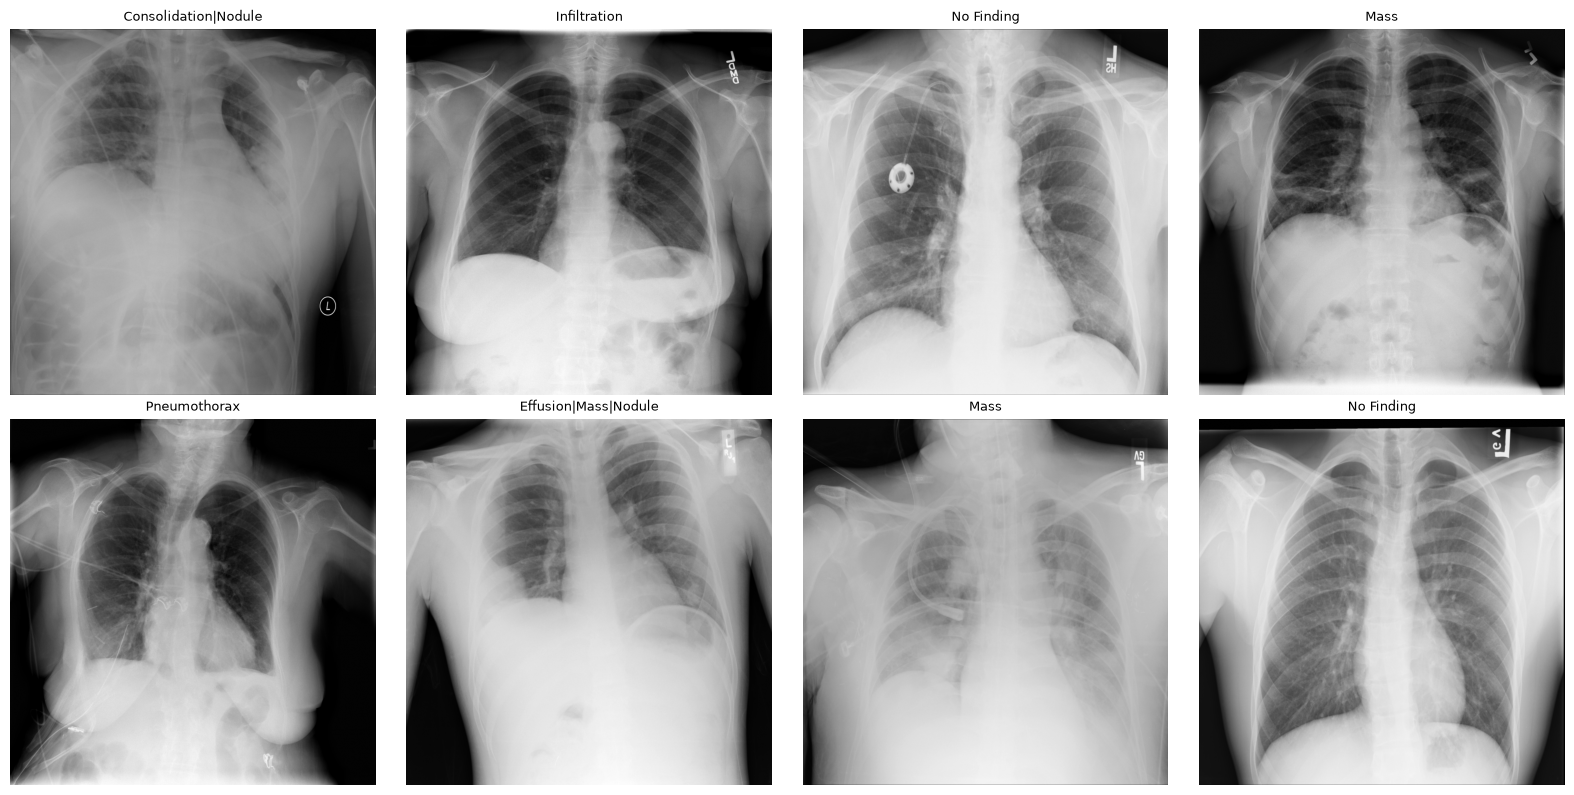

In [8]:
import os
import random
from PIL import Image

# Build a lookup: filename -> full path (since images are split across 12 folders)
image_dir_map = {}
for folder in sorted(os.listdir('../data/raw')):
    if folder.startswith('images_'):
        img_subdir = f'../data/raw/{folder}/images'
        for fname in os.listdir(img_subdir):
            image_dir_map[fname] = os.path.join(img_subdir, fname)

# Sample 8 random images
sample_names = random.sample(list(image_dir_map.keys()), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, fname in zip(axes.flatten(), sample_names):
    img = Image.open(image_dir_map[fname])
    label = df[df['Image Index'] == fname]['Finding Labels'].values[0]
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Cell 8: Image size & mode consistency check

In [9]:
sample_check = random.sample(list(image_dir_map.keys()), 50)

sizes = []
modes = []
for fname in sample_check:
    img = Image.open(image_dir_map[fname])
    sizes.append(img.size)
    modes.append(img.mode)

print("Unique image sizes found:", set(sizes))
print("\nImage mode distribution:")
print(pd.Series(modes).value_counts())

Unique image sizes found: {(1024, 1024)}

Image mode distribution:
L    50
Name: count, dtype: int64
